In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm

from sklearn.metrics import classification_report, r2_score, accuracy_score, recall_score, \
precision_score, f1_score, confusion_matrix, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

**step2:Data  Importing And Analysing**

In [2]:
df= pd.read_csv("mhealth_raw_data.csv")
df

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.449020,-1.01030,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.449020,-1.01030,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.449020,-1.01030,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.456860,-1.00820,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.456860,-1.00820,0.025862,0,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215740,1.7849,-9.8287,0.29725,-0.341370,-0.90056,-0.61493,-3.7198,-8.9071,0.294230,0.041176,-0.99384,-0.480600,0,subject10
1215741,1.8687,-9.8766,0.46236,-0.341370,-0.90056,-0.61493,-3.7160,-8.7455,0.448140,0.041176,-0.99384,-0.480600,0,subject10
1215742,1.6928,-9.9290,0.16631,-0.341370,-0.90056,-0.61493,-3.8824,-9.1155,0.450480,0.041176,-0.99384,-0.480600,0,subject10
1215743,1.5279,-9.6306,0.30458,-0.341370,-0.90056,-0.61493,-3.5564,-9.1441,0.594880,0.041176,-0.99384,-0.480600,0,subject10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 14 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alx       1215745 non-null  float64
 1   aly       1215745 non-null  float64
 2   alz       1215745 non-null  float64
 3   glx       1215745 non-null  float64
 4   gly       1215745 non-null  float64
 5   glz       1215745 non-null  float64
 6   arx       1215745 non-null  float64
 7   ary       1215745 non-null  float64
 8   arz       1215745 non-null  float64
 9   grx       1215745 non-null  float64
 10  gry       1215745 non-null  float64
 11  grz       1215745 non-null  float64
 12  Activity  1215745 non-null  int64  
 13  subject   1215745 non-null  object 
dtypes: float64(12), int64(1), object(1)
memory usage: 129.9+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alx,1215745.0,1.494200,3.826485,-22.1460,0.14131,1.308900,2.575800,20.0540
aly,1215745.0,-9.692878,4.171303,-19.6190,-10.20100,-9.670300,-9.042200,21.1610
alz,1215745.0,-0.954806,5.461803,-19.3730,-2.64940,-0.016456,1.301300,25.0150
glx,1215745.0,-0.001599,0.491217,-2.1466,-0.43599,-0.014842,0.448980,60.4840
gly,1215745.0,-0.616632,0.354641,-7.7899,-0.81801,-0.707320,-0.540340,2.0113
glz,1215745.0,-0.158781,0.546798,-2.6267,-0.59332,-0.190570,0.322200,2.7701
arx,1215745.0,-3.713413,4.763586,-22.3610,-6.07600,-2.977600,-1.193700,19.8640
ary,1215745.0,-5.805526,5.757639,-18.9720,-9.40420,-7.461500,-2.533900,22.1910
arz,1215745.0,2.393880,3.876503,-18.2390,0.12965,1.928100,4.914700,25.7410
grx,1215745.0,-0.276106,0.527689,-8.3392,-0.70588,-0.354900,0.096078,3.3196


In [5]:
df.isnull().sum()

alx         0
aly         0
alz         0
glx         0
gly         0
glz         0
arx         0
ary         0
arz         0
grx         0
gry         0
grz         0
Activity    0
subject     0
dtype: int64

In [6]:
df.duplicated().sum() #number of duplicaated in dataframe rows

np.int64(0)

In [7]:

df.columns= df.columns.str.strip().str.lower().str.replace(" ","_")

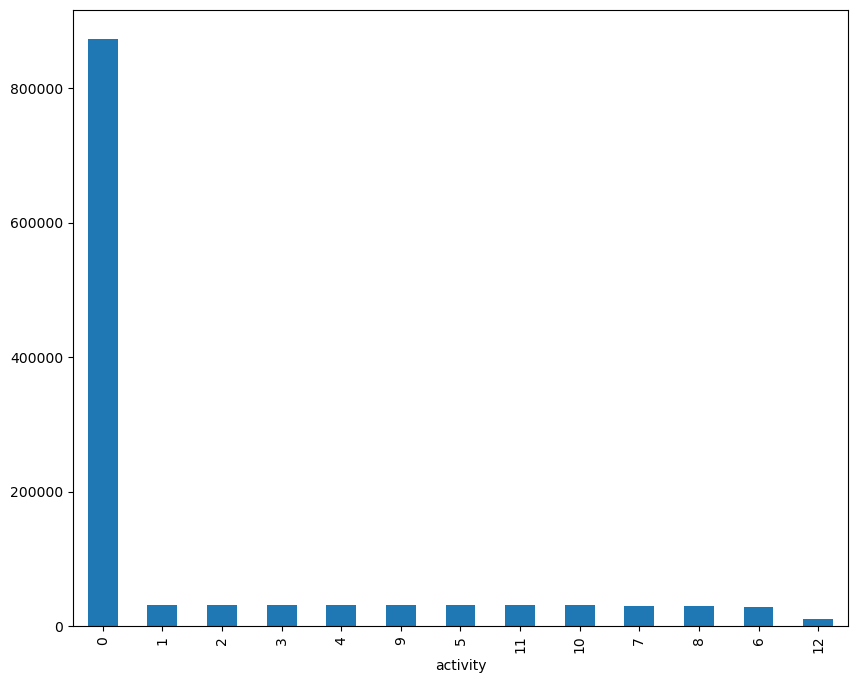

In [8]:
plt.figure(figsize=(10,8))
df['activity'].value_counts().plot.bar()
plt.show()

In [9]:
data_activity_0 = df[df['activity'] ==0]
data_activity_else = df[df['activity'] !=0]
plt.show()

In [10]:
data_actvity_0_sampled = data_activity_0.sample(n=40000, random_state=42)
df = pd.concat([data_actvity_0_sampled ,data_activity_else])

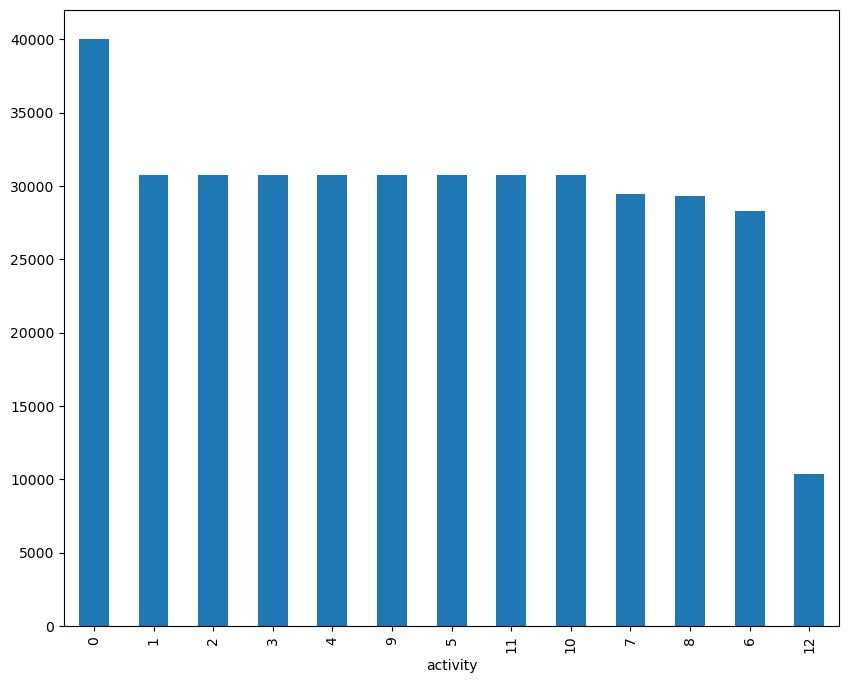

In [11]:
plt.figure(figsize=(10,8))
df['activity'].value_counts().plot.bar()
plt.show()

In [12]:
len(df)

383195

**step3:EDA**

In [13]:
activity_label = { 
0:"None",    
1: "Standing still (1 min)",
2: "Sitting and relaxing (1 min)",
3:"Lying down (1 min)",
4: "Walking (1 min)",
5: "Climbing stairs (1 min)",
6: "Waist bends forward (20x)",
7: "Frontal elevation of arms (20x)",
8: "Knees bending (crouching) (20x)",
9: "Cycling (1 min)",
10: "Jogging (1 min)",
11: "Running (1 min)",
12: "Jump front & back (20x)"
}

=====================Standing still (1 min) - a=====================


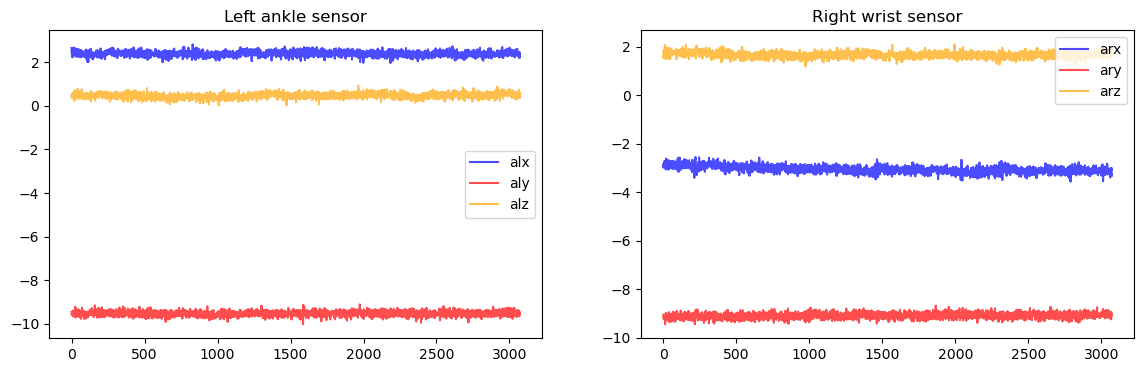

=====================Standing still (1 min) - g=====================


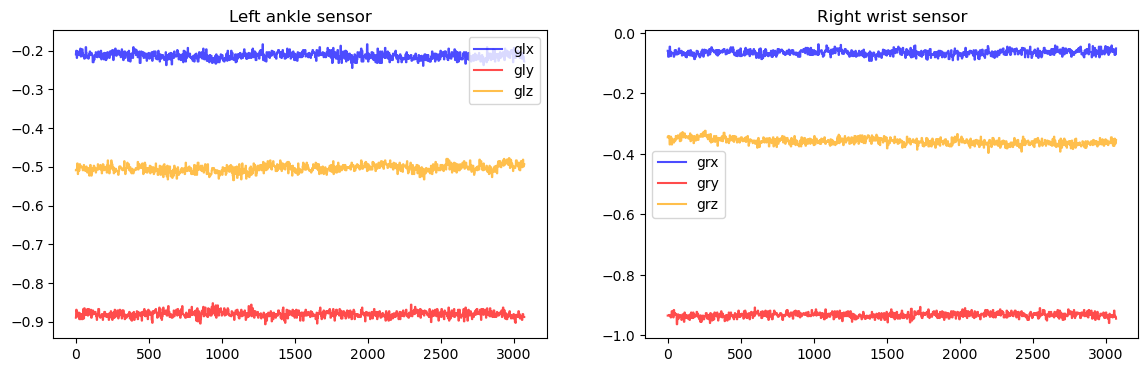

=====================Sitting and relaxing (1 min) - a=====================


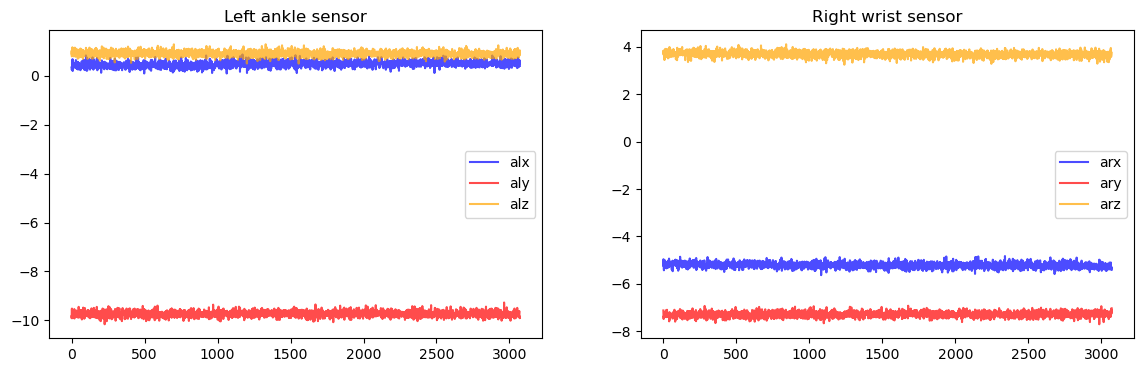

=====================Sitting and relaxing (1 min) - g=====================


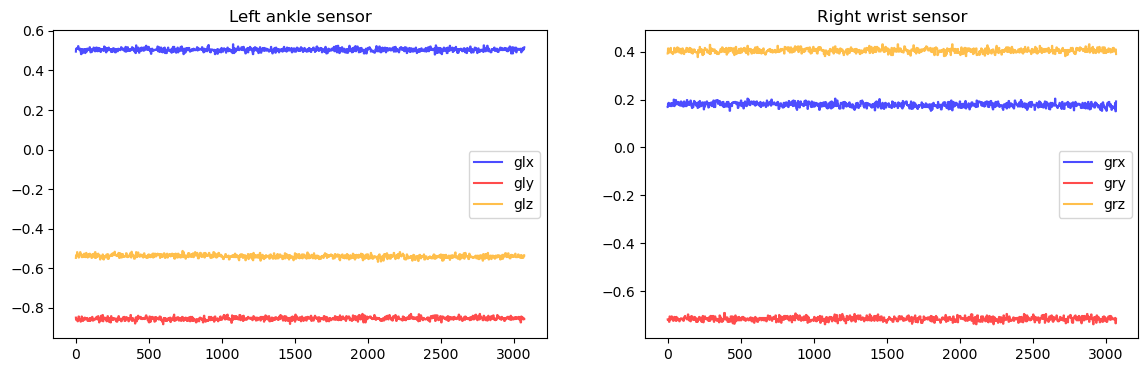

=====================Lying down (1 min) - a=====================


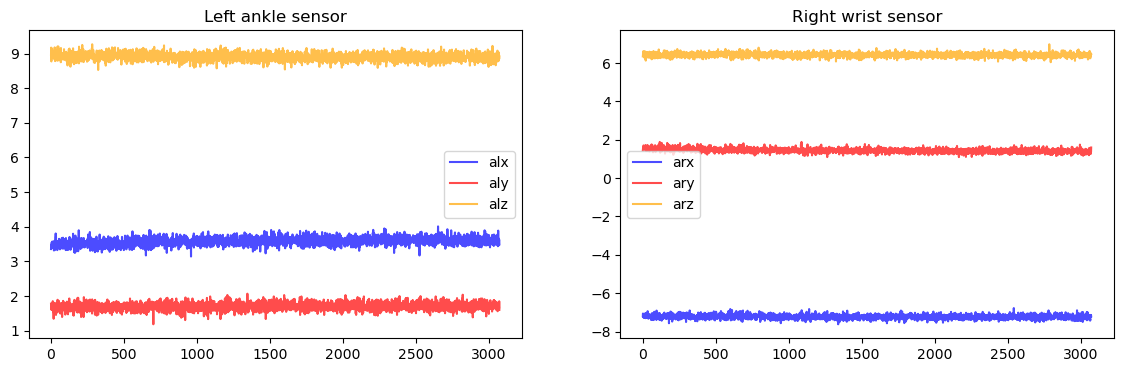

=====================Lying down (1 min) - g=====================


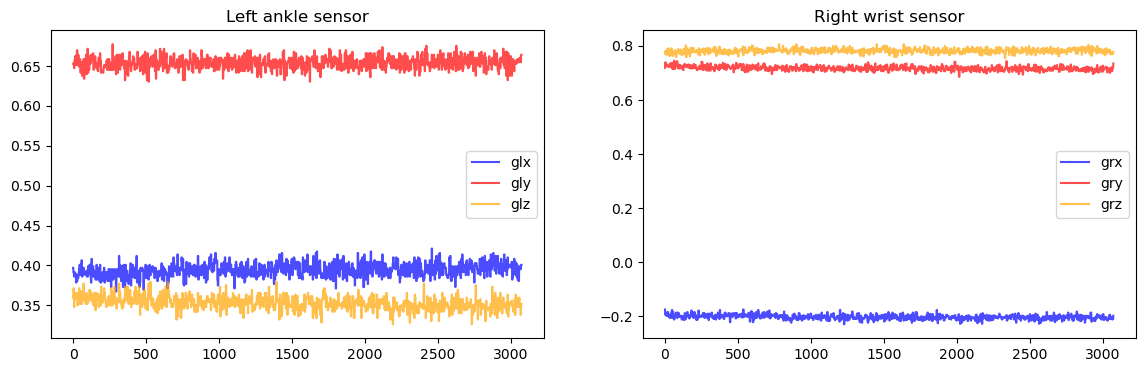

=====================Walking (1 min) - a=====================


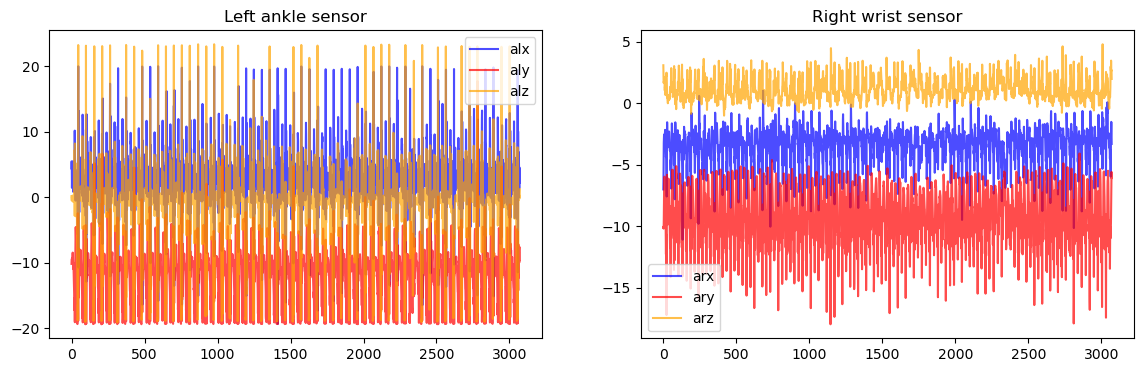

=====================Walking (1 min) - g=====================


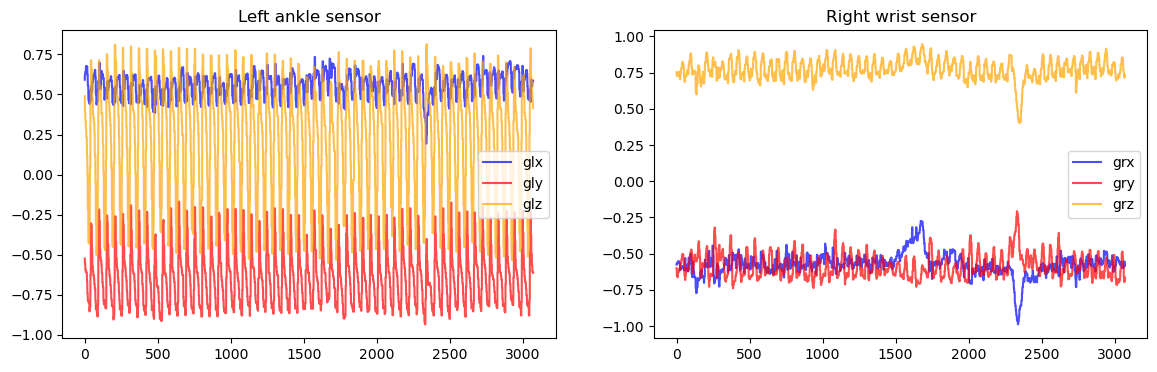

=====================Climbing stairs (1 min) - a=====================


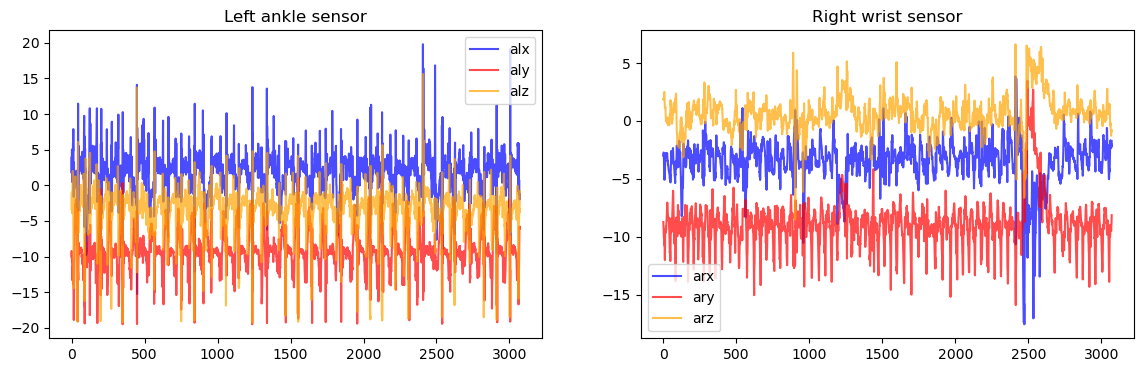

=====================Climbing stairs (1 min) - g=====================


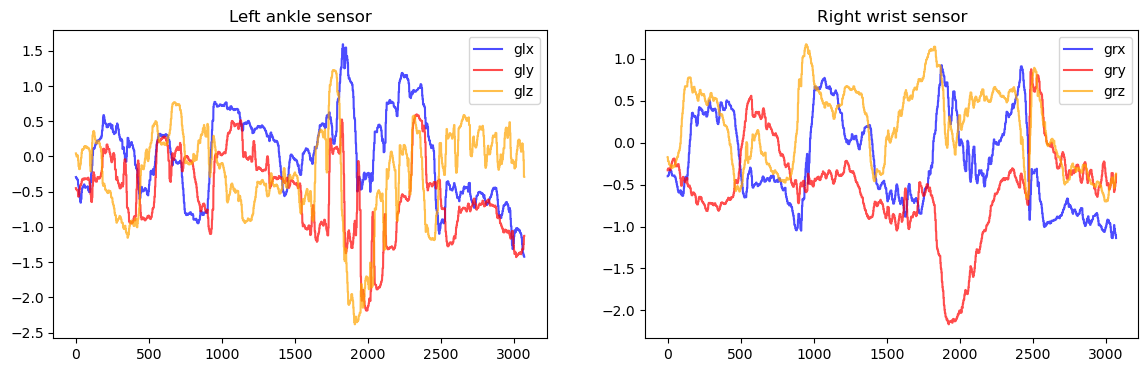

=====================Waist bends forward (20x) - a=====================


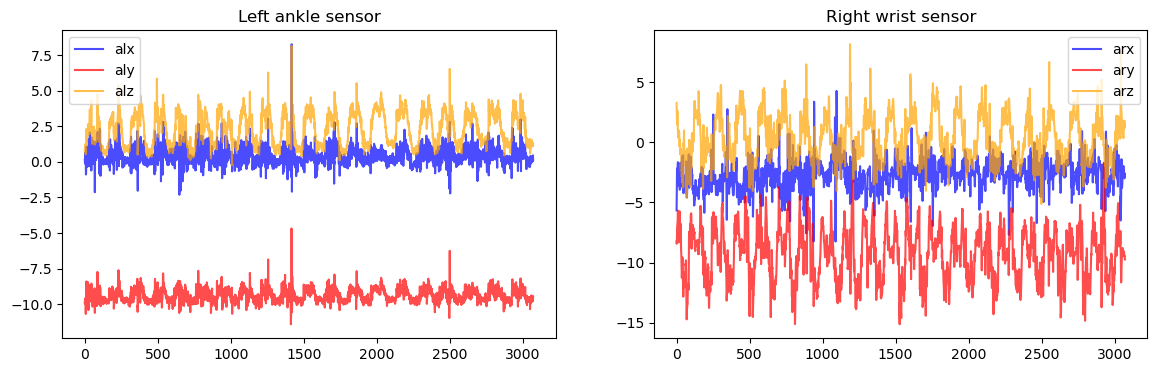

=====================Waist bends forward (20x) - g=====================


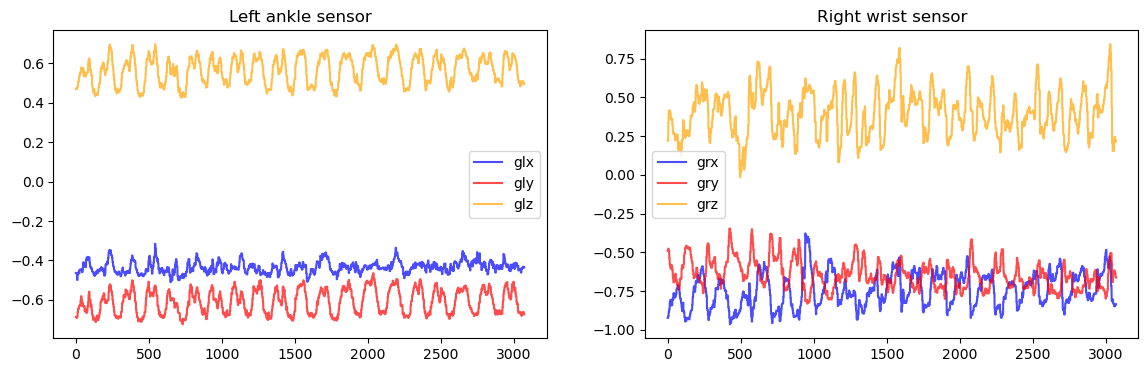

=====================Frontal elevation of arms (20x) - a=====================


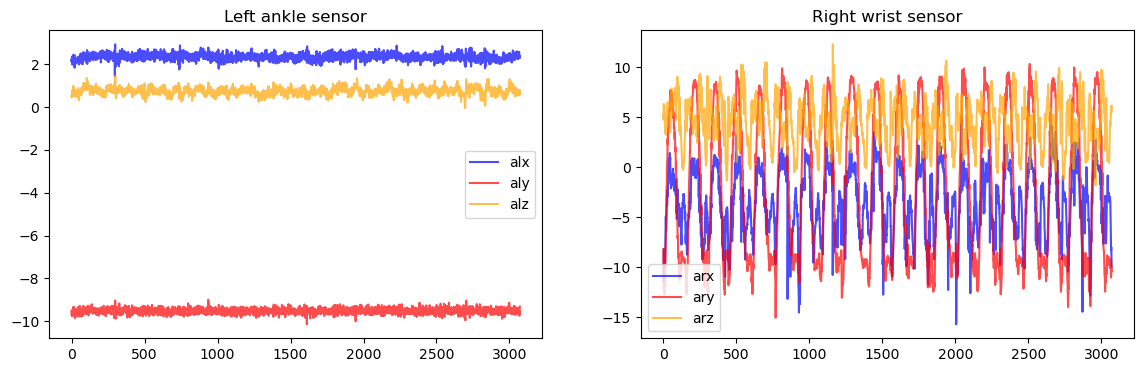

=====================Frontal elevation of arms (20x) - g=====================


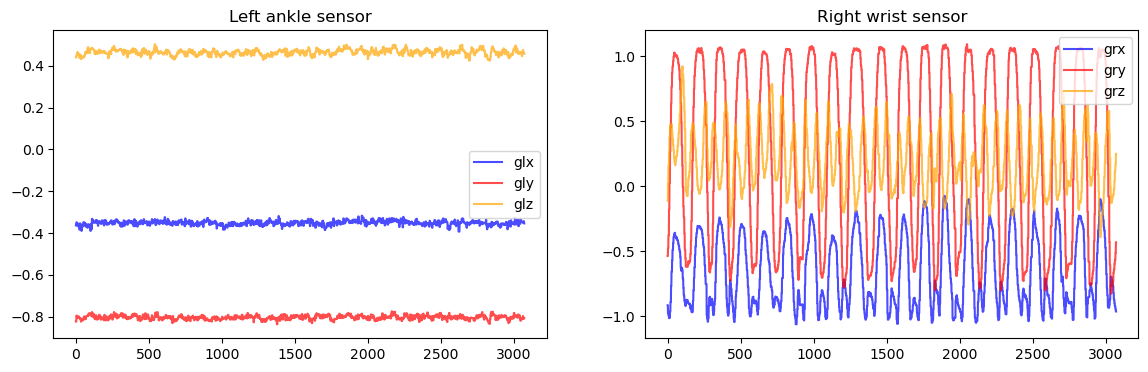

=====================Knees bending (crouching) (20x) - a=====================


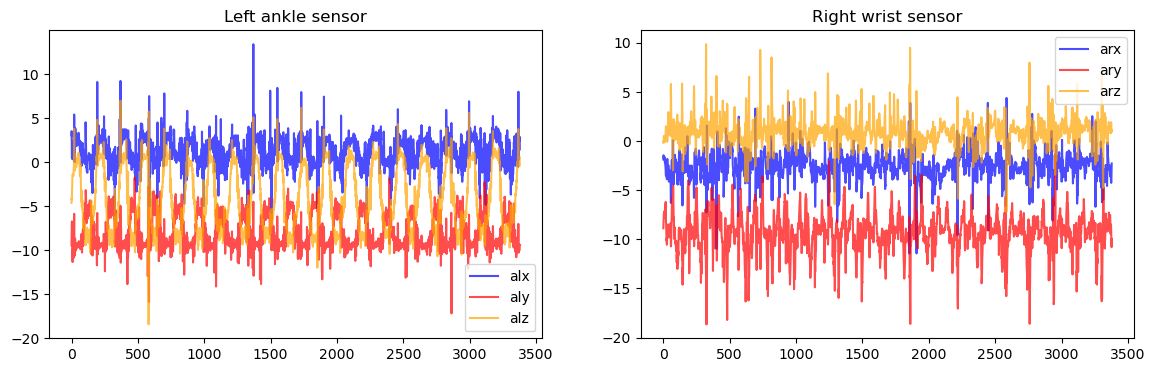

=====================Knees bending (crouching) (20x) - g=====================


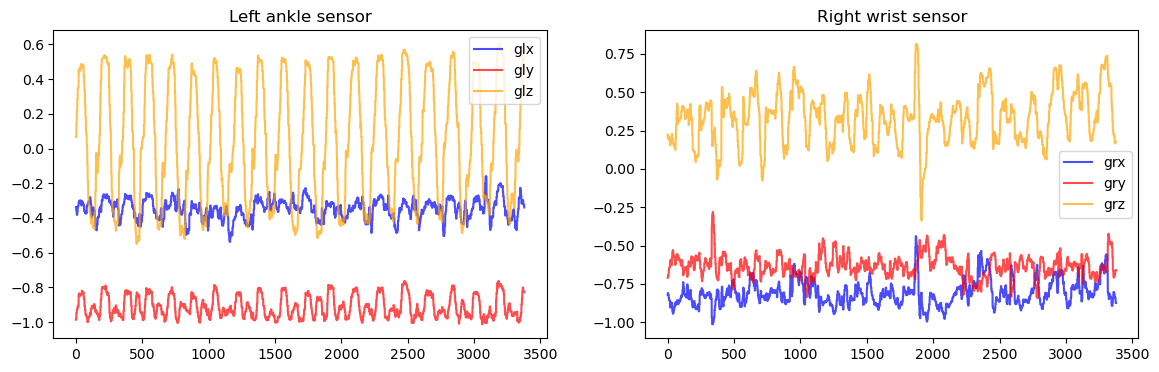

=====================Cycling (1 min) - a=====================


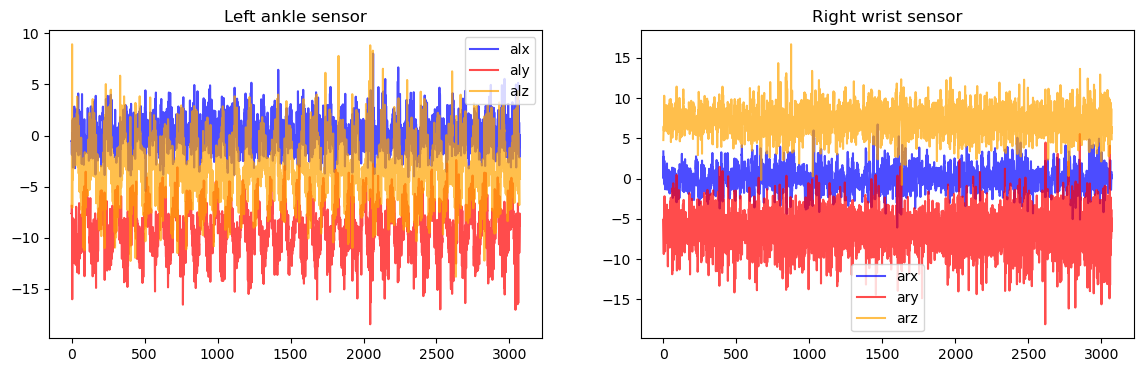

=====================Cycling (1 min) - g=====================


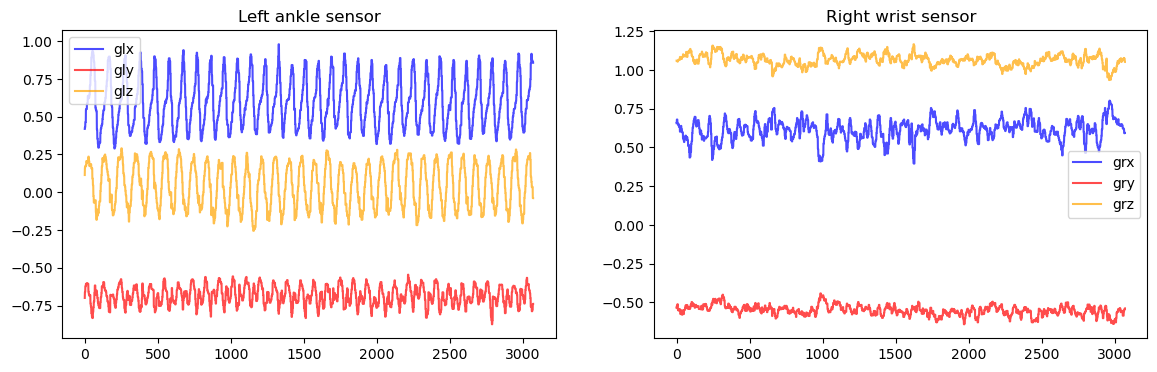

=====================Jogging (1 min) - a=====================


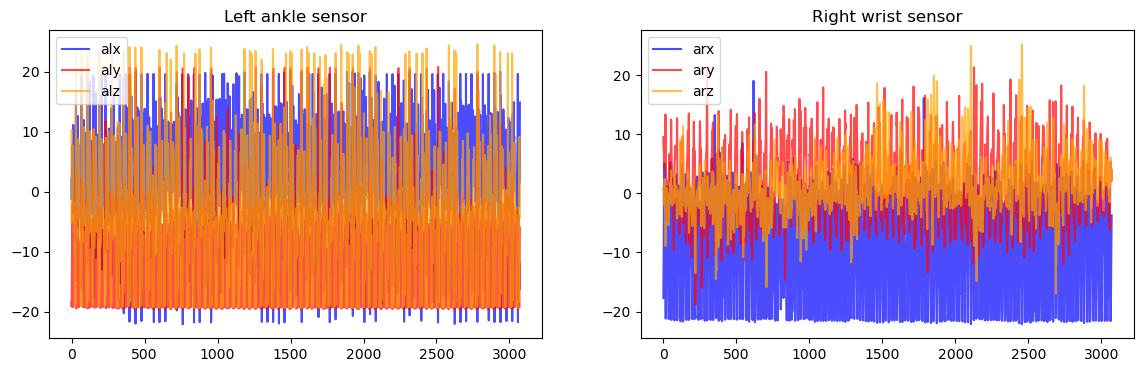

=====================Jogging (1 min) - g=====================


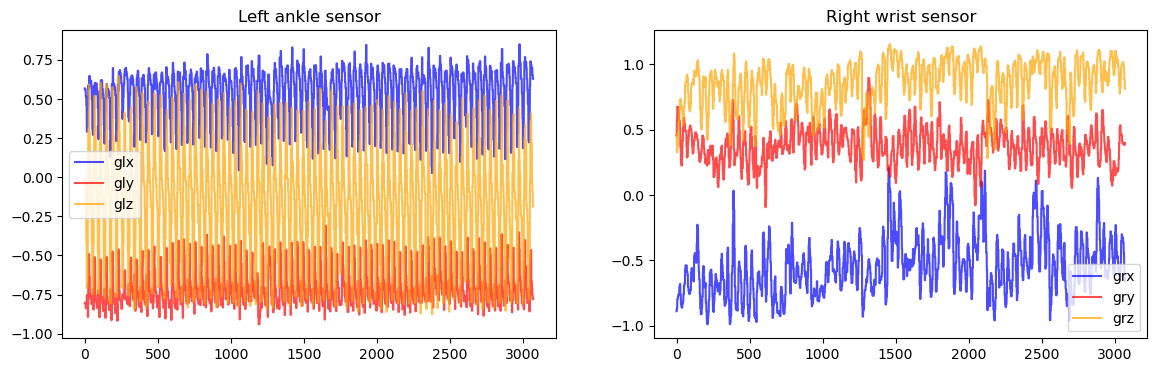

=====================Running (1 min) - a=====================


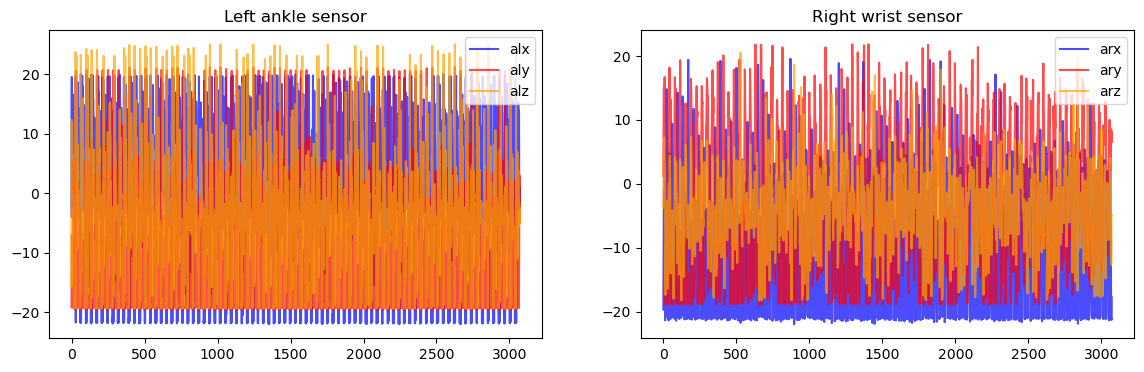

=====================Running (1 min) - g=====================


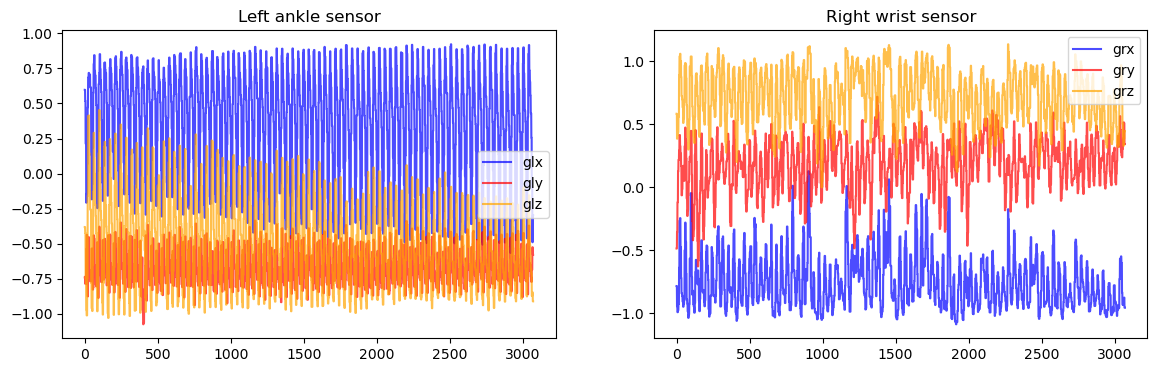

=====================Jump front & back (20x) - a=====================


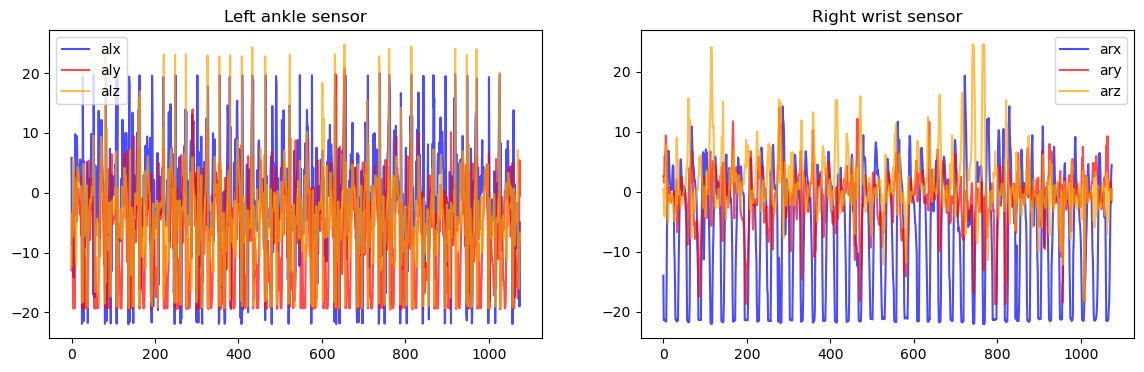

=====================Jump front & back (20x) - g=====================


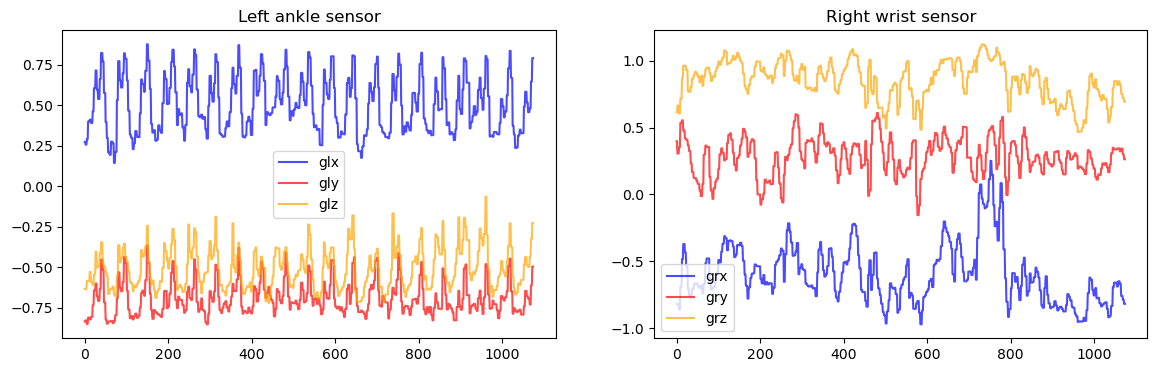

In [14]:
subject1 = df[df['subject'] == 'subject1']
readings = ['a', 'g']

for i in range(1, 13):
    for r in readings:
        print(f"====================={activity_label[i]} - {r}=====================")
        plt.figure(figsize=(14,4))
        
        # Left ankle sensor
        plt.subplot(1, 2, 1)          # there will be hist which is another type of graph
        plt.plot(subject1[subject1['activity'] == i].reset_index(drop=True)[r + "lx"],
                 color='blue', alpha=0.7, label=r + "lx")
        plt.plot(subject1[subject1['activity'] == i].reset_index(drop=True)[r + "ly"],
                 color='red', alpha=0.7, label=r + "ly")
        plt.plot(subject1[subject1['activity'] == i].reset_index(drop=True)[r + "lz"],
                 color='orange', alpha=0.7, label=r + "lz")
        plt.title("Left ankle sensor")
        plt.legend()
        
        # Right wrist sensor
        plt.subplot(1, 2, 2)
        plt.plot(subject1[subject1['activity'] == i].reset_index(drop=True)[r + "rx"],
                 color='blue', alpha=0.7, label=r + "rx")
        plt.plot(subject1[subject1['activity'] == i].reset_index(drop=True)[r + "ry"],
                 color='red', alpha=0.7, label=r + "ry")
        plt.plot(subject1[subject1['activity'] == i].reset_index(drop=True)[r + "rz"],
                 color='orange', alpha=0.7, label=r + "rz")
        plt.title("Right wrist sensor")
        plt.legend()
        
        plt.show()


In [15]:
df['activity']


1212350     0
134482      0
820343      0
718210      0
118798      0
           ..
1213641    12
1213642    12
1213643    12
1213644    12
1213645    12
Name: activity, Length: 383195, dtype: int64

In [16]:
df.activity.value_counts()

activity
0     40000
1     30720
2     30720
3     30720
4     30720
9     30720
5     30720
11    30720
10    30720
7     29441
8     29337
6     28315
12    10342
Name: count, dtype: int64

In [17]:
df["activity_name"] = df["activity"].map(activity_label)
df["activity_name"].value_counts()

activity_name
None                               40000
Standing still (1 min)             30720
Sitting and relaxing (1 min)       30720
Lying down (1 min)                 30720
Walking (1 min)                    30720
Cycling (1 min)                    30720
Climbing stairs (1 min)            30720
Running (1 min)                    30720
Jogging (1 min)                    30720
Frontal elevation of arms (20x)    29441
Knees bending (crouching) (20x)    29337
Waist bends forward (20x)          28315
Jump front & back (20x)            10342
Name: count, dtype: int64

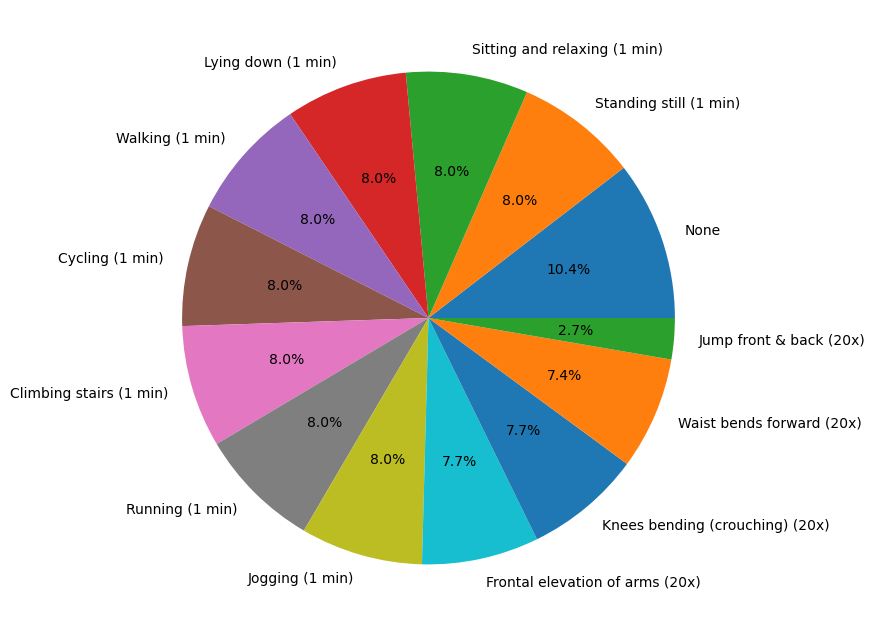

In [18]:
plt.figure(figsize=(12,8))
round(df['activity_name'].value_counts()/df.shape[0]*100,2).plot.pie(autopct ='%2.1f%%')
plt.ylabel("")
plt.show()

In [19]:
df1 = df.copy()

for feature in df1.columns[:-2]:
    lower_range = np.quantile(df1[feature], 0.01)
    upper_range = np.quantile(df1[feature], 0.99)
    print(feature, "range:", lower_range, 'to', upper_range)

    df1 = df1.drop(df1[(df1[feature] > upper_range) | (df1[feature] < lower_range)].index, axis=0)
    print('shape', df1.shape)


alx range: -11.56042 to 19.21306
shape (375531, 15)
aly range: -19.365 to 1.8220700000000012
shape (368057, 15)
alz range: -18.606 to 11.823440000000003
shape (360697, 15)
glx range: -0.75881 to 0.79963
shape (353511, 15)
gly range: -1.0394 to 0.96811
shape (346495, 15)
glz range: -1.0963 to 0.82711
shape (339658, 15)
arx range: -21.464 to 6.8239
shape (332870, 15)
ary range: -18.682 to 10.85
shape (326235, 15)
arz range: -6.409992 to 10.309659999999974
shape (319709, 15)
grx range: -1.0059 to 0.89412
shape (313605, 15)
gry range: -1.1253 to 0.92608
shape (307451, 15)
grz range: -0.66164 to 1.1164
shape (301450, 15)
activity range: 0.0 to 12.0
shape (301450, 15)


In [20]:
df1


,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,activity,subject,activity_name
1212350,1.33590,-9.73940,-1.6611,0.58813,-0.58724,-0.662080,-3.27030,-9.053100,-0.30682,0.401960,-1.06160,0.146550,0,subject10,None
134482,2.52730,-12.73200,-3.8822,0.51763,-0.58537,-0.758350,-4.34630,-10.513000,1.71390,-0.272550,-0.76591,0.851290,0,subject1,None
820343,0.55205,-9.74660,1.5807,0.55288,-0.76173,-0.176820,-5.81550,-8.164300,-2.42900,0.137250,-0.99795,0.521550,0,subject7,None
718210,2.49960,-9.36800,1.8170,0.73655,-0.55159,0.068762,-3.05040,-5.913500,4.65220,0.084314,-0.71047,0.900860,0,subject6,None
373043,4.09450,-19.32600,-9.8733,-0.35807,-0.61726,-0.831040,0.90666,-8.351100,-0.10505,-0.223530,-1.05950,-0.241380,0,subject3,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213636,-0.19979,-0.93484,2.5554,0.63080,-0.52533,-0.679760,-4.02120,-0.082645,0.73545,-0.458820,-1.00000,0.122840,12,subject10,Jump front & back (20x)
1213637,-0.33315,-1.23710,-2.9194,0.63822,-0.42777,-0.748530,-2.25150,-0.414790,0.52093,-0.417650,-1.03700,0.088362,12,subject10,Jump front & back (20x)
1213640,6.77570,-15.07500,7.3974,0.61967,-0.33771,-0.827110,-2.27970,-2.358900,2.11120,-0.417650,-1.03700,0.088362,12,subject10,Jump front & back (20x)
1213641,-2.48730,-19.23300,3.4614,0.61967,-0.33771,-0.827110,-8.23480,-4.965200,2.48090,-0.437250,-1.01850,0.079741,12,subject10,Jump front & back (20x)


***step4:data processing***

In [21]:
le = LabelEncoder()
df['subject']= le.fit_transform(df['subject'])

In [22]:
df['activity'].apply(type).value_counts()

activity
<class 'int'>    383195
Name: count, dtype: int64

In [23]:
df_model = df[df["activity"] != 0].copy()

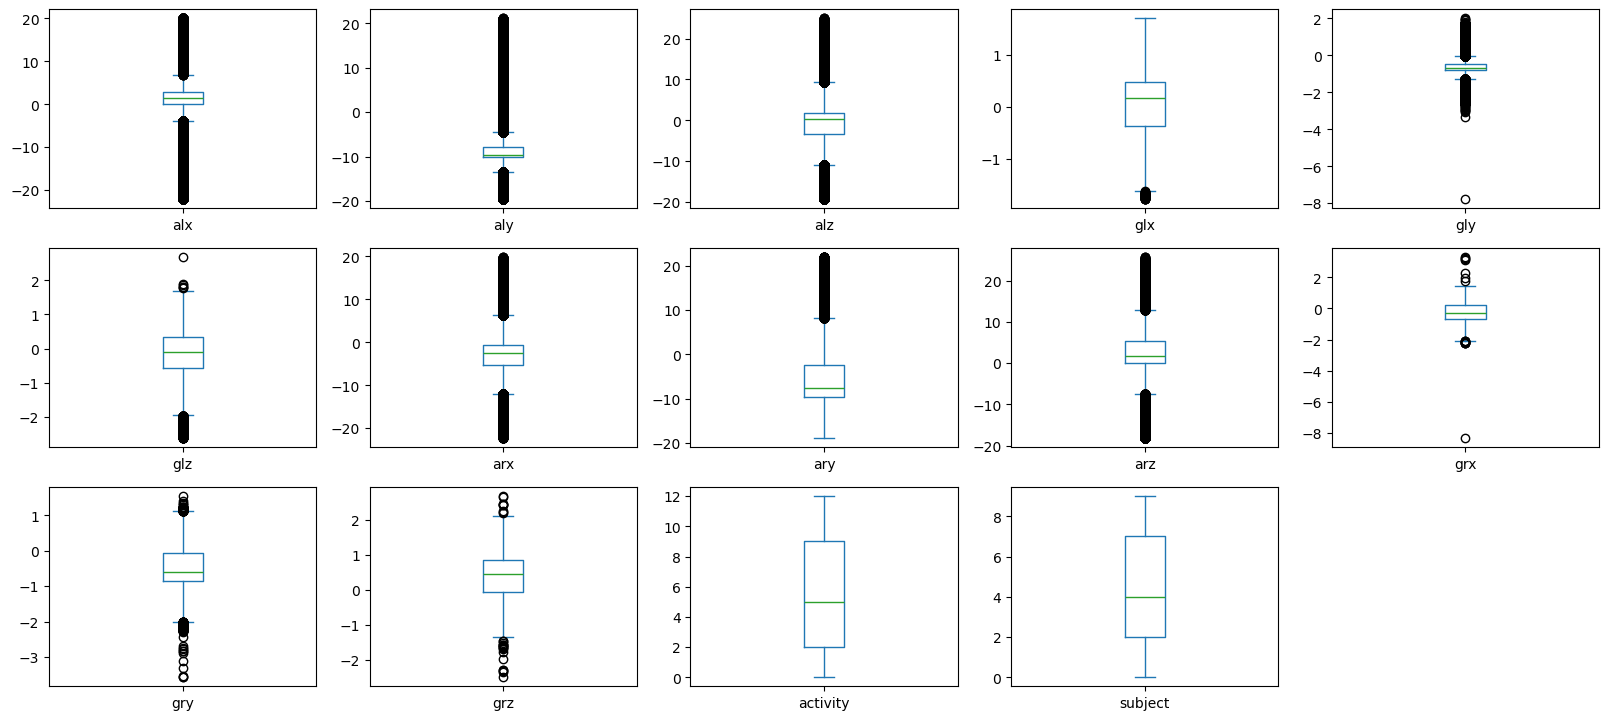

In [24]:
df.plot(kind='box',subplots=True,layout=(5,5),figsize=(20,15))
plt.show()

In [25]:
X=df_model.drop(["activity","activity_name","subject"],axis=1).values
y=df_model["activity_name"].values

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [27]:
ro_scaler = RobustScaler().fit(X_train)
X_train_scaled = ro_scaler.transform(X_train)
X_test_scaled = ro_scaler.transform(X_test)

**step5:building model**

In [43]:
def resultsSummarizer(y_true, y_pred, cm_en=True):
    labels = sorted(np.unique(y_true))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = sensitivity = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    
    if cm_en:
        plt.figure(figsize=(15, 15))

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels
        )

        plt.title('Confusion Matrix')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    print('Accuracy Score: ' + '{:.4%}'.format(acc))
    print('Precision Score: ' + '{:.4%}'.format(prec))
    print('Recall Score: ' + '{:.4%}'.format(rec))
    print('F1 Score: ' + '{:.4%}'.format(f1))

**1:Logistic Regression**

In [44]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


C:\Users\sanje\.conda\envs\ml_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
lr.score(X_train, y_train)

0.6517428398265708

In [31]:
lr.score(X_test, y_test)

0.6534808097996481

In [32]:
lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
lr2.score(X_test_scaled, y_test)

0.6535390855371275

In [34]:
y_pred_lr = lr2.predict(X_test_scaled)

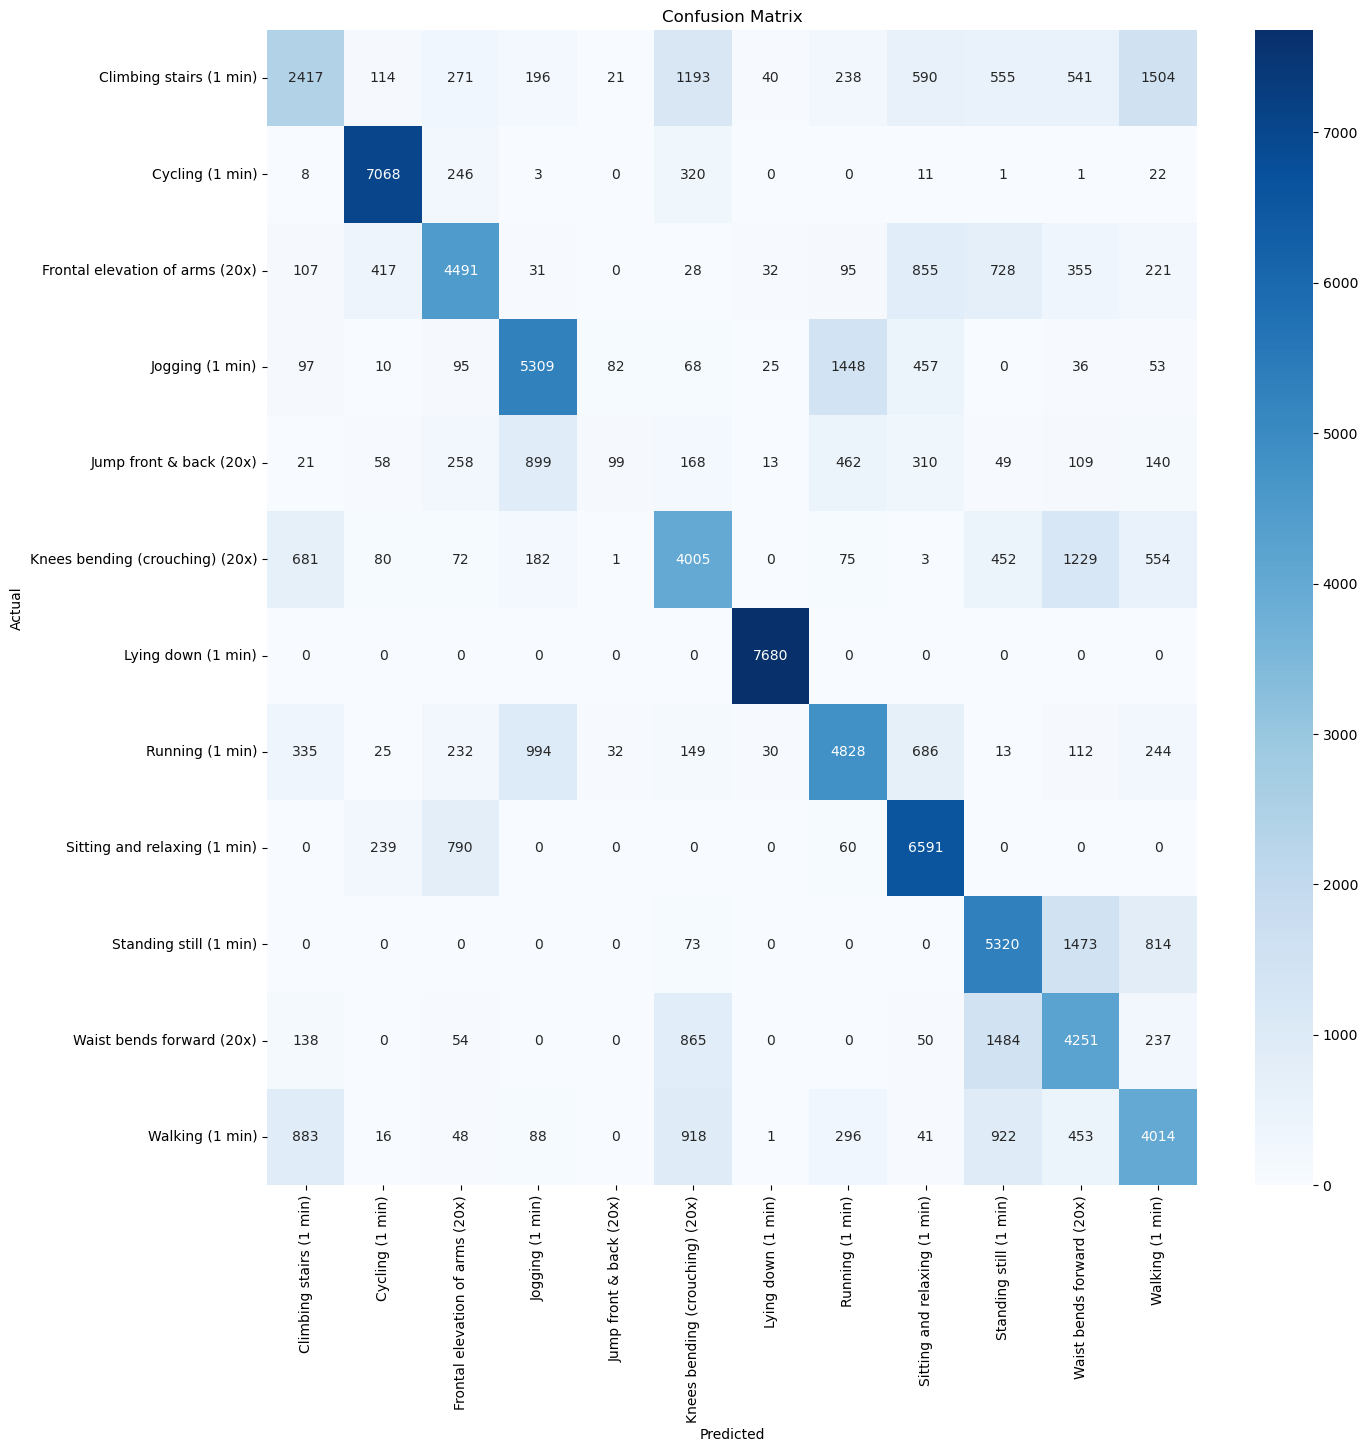

Accuracy Score: 65.3539%
Precision Score: 63.2347%
Recall Score: 61.8632%
F1 Score: 60.8091%


In [35]:
resultsSummarizer(y_test, y_pred_lr)

***KNN***

In [36]:
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
y_pred_knn = knn1.predict(X_test)

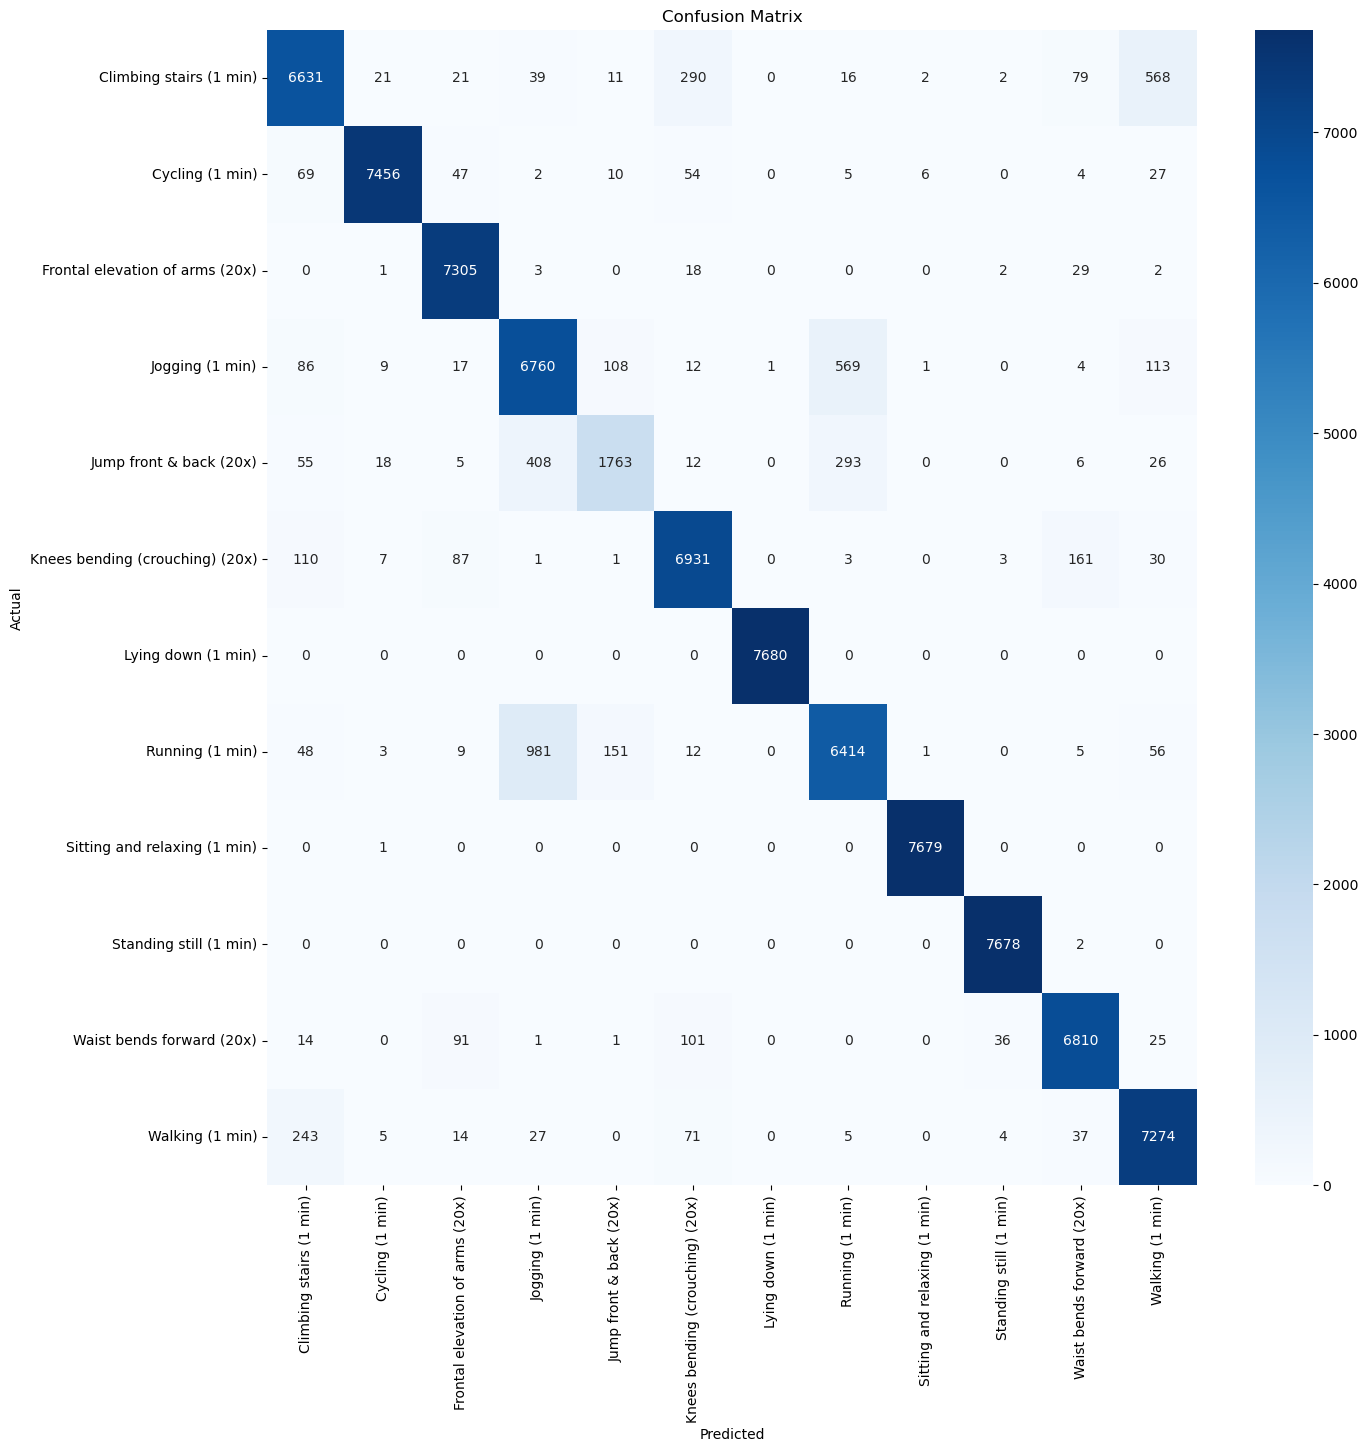

Accuracy Score: 93.6852%
Precision Score: 93.2967%
Recall Score: 92.3140%
F1 Score: 92.6888%


In [38]:
resultsSummarizer(y_test, y_pred_knn)


In [39]:
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_scaled, y_train)
y_pred_knn2 = knn2.predict(X_test_scaled)

In [40]:
resultsSummarizer(y_test, y_pred_knn2, cm_en=False)

Accuracy Score: 97.7144%
Precision Score: 97.6128%
Recall Score: 96.5682%
F1 Score: 96.9981%


In [41]:
for n in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    print(f"\n=========== No of Neighbors: {n} ===========\n")
    resultsSummarizer(y_test, y_pred, cm_en=False)


=========== No of Neighbors: 1 ===========

Accuracy Score: 98.0245%
Precision Score: 97.8043%
Recall Score: 97.1919%
F1 Score: 97.4653%

=========== No of Neighbors: 2 ===========

Accuracy Score: 97.6911%
Precision Score: 97.5429%
Recall Score: 96.6853%
F1 Score: 97.0269%

=========== No of Neighbors: 3 ===========

Accuracy Score: 97.8788%
Precision Score: 97.7626%
Recall Score: 96.8481%
F1 Score: 97.2351%

=========== No of Neighbors: 4 ===========

Accuracy Score: 97.7237%
Precision Score: 97.6273%
Recall Score: 96.5977%
F1 Score: 97.0166%

=========== No of Neighbors: 5 ===========

Accuracy Score: 97.7144%
Precision Score: 97.6128%
Recall Score: 96.5682%
F1 Score: 96.9981%

=========== No of Neighbors: 6 ===========

Accuracy Score: 97.5746%
Precision Score: 97.4899%
Recall Score: 96.3128%
F1 Score: 96.7811%

=========== No of Neighbors: 7 ===========

Accuracy Score: 97.5128%
Precision Score: 97.4198%
Recall Score: 96.2967%
F1 Score: 96.7496%

=========== No of Neighbors: 8 ==

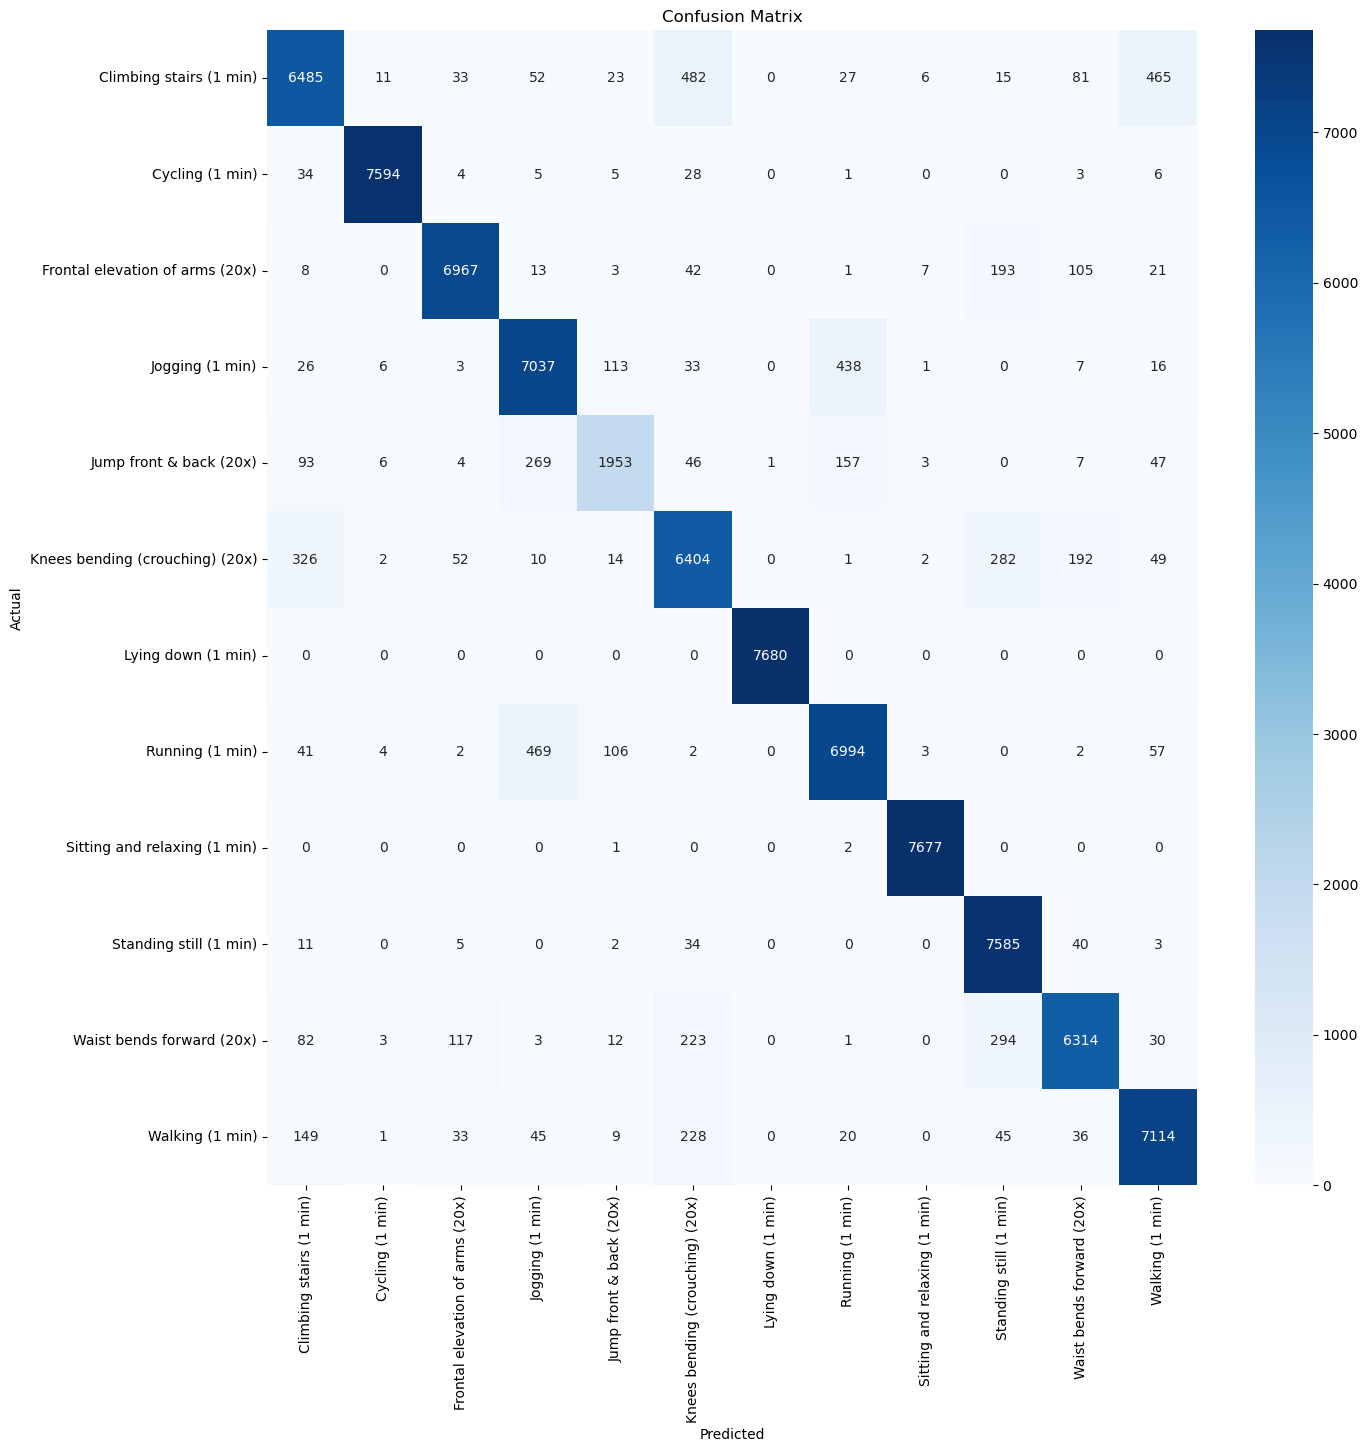

Accuracy Score: 93.0127%
Precision Score: 92.6908%
Recall Score: 92.0054%
F1 Score: 92.2837%


In [42]:
dt = DecisionTreeClassifier(max_depth=14)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

resultsSummarizer(y_test, y_pred_dt)

In [46]:
import joblib

In [47]:
final_model = KNeighborsClassifier(n_neighbors=3)
final_model.fit(X_train_scaled, y_train)

joblib.dump(final_model, "activity_model.joblib")
joblib.dump(ro_scaler, "activity_scaler.joblib")

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [48]:
import joblib
import pandas as pd

model = joblib.load("activity_model.joblib")
scaler = joblib.load("activity_scaler.joblib")

sample_input = [[
    2.1849, -9.6967, 0.63077,
    0.1039, -0.84053, -0.68762,
    -8.6499, -4.5781, 0.18776,
    -0.44902, -1.0103, 0.034483
]]

sample_scaled = scaler.transform(sample_input)
prediction = model.predict(sample_scaled)

print("Predicted Activity:", prediction[0])

Predicted Activity: Waist bends forward (20x)
